In [1]:
!pip install scipy numpy Pillow torchvision tqdm

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os, shutil, random, zipfile
import numpy as np
import h5py
import scipy.io as sio
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
print("Imports OK")

Imports OK


In [3]:
# ── CHANGE THESE TWO PATHS ──────────────────────────────────────────
SOURCE_ROOT = r"C:\Users\kshit\OneDrive\Desktop\Raw_dataset"   # folder with 4 class subfolders
OUTPUT_ROOT = r"C:\Augmented_v2"       # output location
# ────────────────────────────────────────────────────────────────────

CLASSES = ["glioma", "meningioma", "pituitary", "no_tumor"]

# 60 / 20 / 20 split ratios
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20
# TEST gets the remainder (~0.20)

N_AUG = 6     # augmentation variants per training image

PRESERVE_FIELDS = ["PID", "label", "tumorBorder", "tumorMask"]
IMAGE_FIELD     = "image"

print(f"Source      : {SOURCE_ROOT}")
print(f"Output      : {OUTPUT_ROOT}")
print(f"Split ratio : {TRAIN_RATIO:.0%} train / {VAL_RATIO:.0%} val / {1-TRAIN_RATIO-VAL_RATIO:.0%} test")
print(f"Augmentations per train image: {N_AUG}")


Source      : C:\Users\kshit\OneDrive\Desktop\Raw_dataset
Output      : C:\Augmented_v2
Split ratio : 60% train / 20% val / 20% test
Augmentations per train image: 6


In [4]:
def get_format(p):
    """Detect whether a .mat file is HDF5/v7.3 or classic MATLAB v5."""
    # Try opening as HDF5 first — most reliable method
    try:
        import h5py
        with h5py.File(str(p), 'r') as f:
            _ = f.keys()
        return 'hdf5'
    except Exception:
        return 'v5'


def load_mat(mat_path):
    """
    Returns
    -------
    img  : float64 ndarray (H, W)
    meta : dict of preserved fields
    fmt  : 'hdf5' or 'v5'
    """
    fmt = get_format(mat_path)
    if fmt == 'hdf5':
        with h5py.File(str(mat_path), 'r') as f:
            img  = f['cjdata'][IMAGE_FIELD][()].astype(np.float64)
            meta = {field: f['cjdata'][field][()]
                    for field in PRESERVE_FIELDS if field in f['cjdata']}
        return img, meta, 'hdf5'
    else:
        m  = sio.loadmat(str(mat_path))
        cj = m['cjdata']
        try:    img = cj['image'][0, 0].astype(np.float64)
        except: img = cj[0, 0]['image'].astype(np.float64)
        meta = {}
        for field in PRESERVE_FIELDS:
            try:    meta[field] = cj[field][0, 0]
            except:
                try: meta[field] = cj[0, 0][field]
                except: meta[field] = np.array([])
        return img, meta, 'v5'


def save_mat(out_path, img_array, meta, fmt):
    """Save augmented image preserving original format and non-image fields."""
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    img_save = np.clip(np.round(img_array), -32768, 32767).astype(np.int16)
    if fmt == 'hdf5':
        with h5py.File(str(out_path), 'w') as f:
            grp = f.create_group('cjdata')
            grp.create_dataset(IMAGE_FIELD, data=img_save)
            for field, data in meta.items():
                if np.asarray(data).size > 0:
                    grp.create_dataset(field, data=data)
    else:
        cj = {IMAGE_FIELD: img_save}
        cj.update({k: v for k, v in meta.items() if np.asarray(v).size > 0})
        sio.savemat(str(out_path), {'cjdata': cj})


# ── PIL helpers ──────────────────────────────────────────────────────

def img_to_pil(img):
    """float64 (H,W) → uint8 PIL RGB for torchvision transforms."""
    mn, mx = img.min(), img.max()
    norm = (img - mn) / (mx - mn + 1e-8) * 255.0
    return Image.fromarray(norm.astype(np.uint8), mode='L').convert('RGB')


def pil_to_img(pil, original_img):
    """uint8 PIL RGB → float64 (H,W) rescaled to original value range."""
    mn, mx = original_img.min(), original_img.max()
    gray = np.array(pil.convert('L'), dtype=np.float64) / 255.0
    return gray * (mx - mn) + mn

print("Helpers defined — format detection uses h5py.File() probe (robust).")


Helpers defined — format detection uses h5py.File() probe (robust).


In [5]:
AUGMENTATIONS = [
    ("original",    T.Compose([T.ToTensor(), T.ToPILImage()])),   # identity
    ("hflip",       T.RandomHorizontalFlip(p=1.0)),
    ("vflip",       T.RandomVerticalFlip(p=1.0)),
    ("rotation20",  T.RandomRotation(degrees=(20, 20))),
    ("colorjitter", T.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.1)),
    ("affine",      T.RandomAffine(degrees=10, translate=(0.1, 0.1),
                                   scale=(0.9, 1.1), shear=10)),
]
assert len(AUGMENTATIONS) == N_AUG, f"N_AUG={N_AUG} but {len(AUGMENTATIONS)} transforms defined"

print(f"{len(AUGMENTATIONS)} variants:")
for name, _ in AUGMENTATIONS:
    print(f"  {name}")

6 variants:
  original
  hflip
  vflip
  rotation20
  colorjitter
  affine


File   : glioma_001.mat
Format : hdf5
Shape  : (512, 512)   Range: [0, 4284]
Meta   : {'PID': (6, 1), 'label': (1, 1), 'tumorBorder': (1, 64), 'tumorMask': (512, 512)}


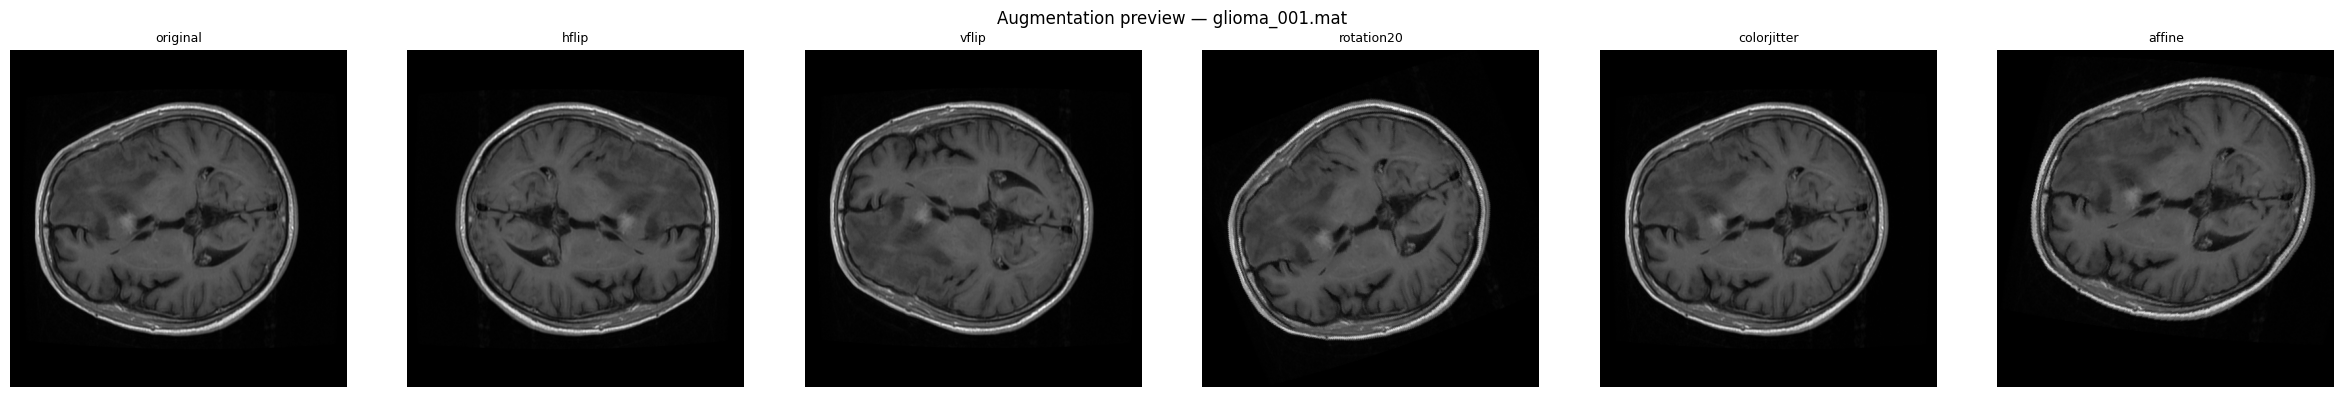

Preview saved → augmentation_preview.png


In [6]:
# Show one sample and all 6 augmented variants
sample = next(Path(SOURCE_ROOT).rglob('*.mat'))
img0, meta0, fmt0 = load_mat(sample)
pil0 = img_to_pil(img0)

print(f"File   : {sample.name}")
print(f"Format : {fmt0}")
print(f"Shape  : {img0.shape}   Range: [{img0.min():.0f}, {img0.max():.0f}]")
print(f"Meta   : { {k: np.asarray(v).shape for k, v in meta0.items()} }")

fig, axes = plt.subplots(1, N_AUG, figsize=(4*N_AUG, 4))
fig.suptitle(f"Augmentation preview — {sample.name}", fontsize=12)
for ax, (name, tf) in zip(axes, AUGMENTATIONS):
    aug_pil = tf(pil0)
    if aug_pil.size != pil0.size:
        aug_pil = aug_pil.resize(pil0.size, Image.BILINEAR)
    ax.imshow(np.array(aug_pil.convert('L')), cmap='gray')
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig("augmentation_preview.png", dpi=120)
plt.show()
print("Preview saved → augmentation_preview.png")

In [7]:
# Test-load every file to detect corrupt / unreadable ones before we start
class_readable = {}   # cls → list of readable Path objects
class_skipped  = {}   # cls → list of (name, error)

for cls in CLASSES:
    cls_dir = Path(SOURCE_ROOT) / cls
    if not cls_dir.exists():
        print(f"⚠️  Folder not found: {cls_dir}")
        class_readable[cls] = []
        class_skipped[cls]  = []
        continue

    all_files = sorted(cls_dir.glob('*.mat'))
    readable, skipped = [], []
    for f in tqdm(all_files, desc=f'Scanning {cls}'):
        try:
            load_mat(f)
            readable.append(f)
        except Exception as e:
            skipped.append((f.name, str(e)))

    class_readable[cls] = readable
    class_skipped[cls]  = skipped
    print(f"{cls:<15} readable={len(readable)}  skipped={len(skipped)}")
    if skipped:
        for name, err in skipped[:3]:
            print(f"    SKIP {name}: {err}")

print("\nScan complete.")

Scanning glioma: 100%|███████████████████████████████████████████████████████████████| 700/700 [00:15<00:00, 44.01it/s]


glioma          readable=700  skipped=0


Scanning meningioma: 100%|███████████████████████████████████████████████████████████| 700/700 [00:20<00:00, 33.40it/s]


meningioma      readable=700  skipped=0


Scanning pituitary: 100%|████████████████████████████████████████████████████████████| 700/700 [00:20<00:00, 34.43it/s]


pituitary       readable=700  skipped=0


Scanning no_tumor: 100%|█████████████████████████████████████████████████████████████| 700/700 [00:14<00:00, 48.61it/s]

no_tumor        readable=700  skipped=0

Scan complete.


In [8]:
def split_files(readable):
    """Randomly split a list of files 60/20/20."""
    files = readable[:]
    random.shuffle(files)
    n       = len(files)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    # Trim train to nearest multiple of N_AUG for clean augmentation output
    n_train = (n_train // N_AUG) * N_AUG
    train   = files[:n_train]
    val     = files[n_train : n_train + n_val]
    test    = files[n_train + n_val:]
    return train, val, test


class_splits = {}   # cls → (train_files, val_files, test_files)

print(f"{'Class':<15} {'Total':>6} {'Train':>7} {'TrainOut':>9} {'Val':>5} {'Test':>5}")
print('-' * 52)

for cls in CLASSES:
    readable = class_readable.get(cls, [])
    if not readable:
        print(f"{cls:<15}  *** no readable files ***")
        class_splits[cls] = ([], [], [])
        continue

    train_files, val_files, test_files = split_files(readable)
    class_splits[cls] = (train_files, val_files, test_files)

    train_out = len(train_files) * N_AUG
    print(f"{cls:<15} {len(readable):>6} {len(train_files):>7} {train_out:>9} {len(val_files):>5} {len(test_files):>5}")

print()
total_train = sum(len(t) * N_AUG for t, v, te in class_splits.values())
total_val   = sum(len(v)          for t, v, te in class_splits.values())
total_test  = sum(len(te)         for t, v, te in class_splits.values())
print(f"Expected output  →  train: {total_train}   val: {total_val}   test: {total_test}")
print(f"Grand total      →  {total_train + total_val + total_test} .mat files")


Class            Total   Train  TrainOut   Val  Test
----------------------------------------------------
glioma             700     420      2520   140   140
meningioma         700     420      2520   140   140
pituitary          700     420      2520   140   140
no_tumor           700     420      2520   140   140

Expected output  →  train: 10080   val: 560   test: 560
Grand total      →  11200 .mat files


In [9]:
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        d = Path(OUTPUT_ROOT) / split / cls
        if d.exists():
            shutil.rmtree(d)
        d.mkdir(parents=True)

print("Output folders created (old data cleared):")
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        print(f"  {OUTPUT_ROOT}/{split}/{cls}/")

Output folders created (old data cleared):
  C:\Augmented_v2/train/glioma/
  C:\Augmented_v2/train/meningioma/
  C:\Augmented_v2/train/pituitary/
  C:\Augmented_v2/train/no_tumor/
  C:\Augmented_v2/val/glioma/
  C:\Augmented_v2/val/meningioma/
  C:\Augmented_v2/val/pituitary/
  C:\Augmented_v2/val/no_tumor/
  C:\Augmented_v2/test/glioma/
  C:\Augmented_v2/test/meningioma/
  C:\Augmented_v2/test/pituitary/
  C:\Augmented_v2/test/no_tumor/


In [10]:
all_errors = []

for cls in CLASSES:
    train_files, val_files, test_files = class_splits[cls]
    if not train_files and not val_files:
        print(f"SKIP {cls} — no files")
        continue

    out_train = Path(OUTPUT_ROOT) / 'train' / cls
    out_val   = Path(OUTPUT_ROOT) / 'val'   / cls
    out_test  = Path(OUTPUT_ROOT) / 'test'  / cls

    print(f"\n{'='*60}")
    print(f"  {cls.upper()}   train_src={len(train_files)}  val={len(val_files)}  test={len(test_files)}")
    print(f"{'='*60}")

    prefix = cls.upper()   # e.g. MENINGIOMA, GLIOMA, PITUITARY, NO_TUMOR

    # TRAIN — augment × N_AUG, rename as CLASS_NNNN_augname.mat
    counter = 1
    for src in tqdm(train_files, desc=f'train/{cls}'):
        for aug_name, tf in AUGMENTATIONS:
            try:
                img, meta, fmt = load_mat(src)
                pil     = img_to_pil(img)
                aug_pil = tf(pil)
                if aug_pil.size != pil.size:
                    aug_pil = aug_pil.resize(pil.size, Image.BILINEAR)
                new_img  = pil_to_img(aug_pil, img)
                out_name = f"{prefix}_{counter:04d}_{aug_name}.mat"
                save_mat(out_train / out_name, new_img, meta, fmt)
            except Exception as e:
                all_errors.append((cls, src.name, aug_name, str(e)))
                print(f"\n  ERROR {src.name} [{aug_name}]: {e}")
        counter += 1

    # VAL — copy with new name CLASS_NNNN.mat
    for idx, src in enumerate(tqdm(val_files, desc=f'val/{cls}'), start=1):
        out_name = f"{prefix}_{idx:04d}.mat"
        shutil.copy2(src, out_val / out_name)

    # TEST — copy with new name CLASS_NNNN.mat
    for idx, src in enumerate(tqdm(test_files, desc=f'test/{cls}'), start=1):
        out_name = f"{prefix}_{idx:04d}.mat"
        shutil.copy2(src, out_test / out_name)

print("\n✅ All classes processed!")
if all_errors:
    print(f"\n⚠️  {len(all_errors)} errors — first 10:")
    for row in all_errors[:10]:
        print(' ', row)



  GLIOMA   train_src=420  val=140  test=140


test/glioma: 100%|██████████████████████████████████████████████████████████████████| 140/140 [00:01<00:00, 134.13it/s]



  MENINGIOMA   train_src=420  val=140  test=140


test/meningioma: 100%|███████████████████████████████████████████████████████████████| 140/140 [00:02<00:00, 66.32it/s]



  PITUITARY   train_src=420  val=140  test=140


test/pituitary: 100%|███████████████████████████████████████████████████████████████| 140/140 [00:00<00:00, 310.65it/s]



  NO_TUMOR   train_src=420  val=140  test=140


test/no_tumor: 100%|████████████████████████████████████████████████████████████████| 140/140 [00:00<00:00, 226.98it/s]


✅ All classes processed!


In [11]:
print(f"{'Split':<8} {'Class':<15} {'Files':>6}")
print('-' * 32)
grand = 0
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        n = len(list((Path(OUTPUT_ROOT) / split / cls).glob('*.mat')))
        grand += n
        print(f"{split:<8} {cls:<15} {n:>6}")
    print()

print(f"Grand total: {grand} .mat files")
print()

total_train = sum(len(t) * N_AUG for t, v, te in class_splits.values())
total_val   = sum(len(v)          for t, v, te in class_splits.values())
total_test  = sum(len(te)         for t, v, te in class_splits.values())
expected = total_train + total_val + total_test
print(f"Expected breakdown:")
for cls in CLASSES:
    t, v, te = class_splits[cls]
    print(f"  {cls:<15}  train={len(t)*N_AUG}  val={len(v)}  test={len(te)}")
print()
print(f"{'✅ Counts match!' if grand == expected else '❌ Count mismatch — check errors above'}")


Split    Class            Files
--------------------------------
train    glioma            2520
train    meningioma        2520
train    pituitary         2520
train    no_tumor          2520

val      glioma             140
val      meningioma         140
val      pituitary          140
val      no_tumor           140

test     glioma             140
test     meningioma         140
test     pituitary          140
test     no_tumor           140

Grand total: 11200 .mat files

Expected breakdown:
  glioma           train=2520  val=140  test=140
  meningioma       train=2520  val=140  test=140
  pituitary        train=2520  val=140  test=140
  no_tumor         train=2520  val=140  test=140

✅ Counts match!


In [14]:
zip_path = Path(OUTPUT_ROOT) / 'brain_tumor_augmented.zip'
all_mats = sorted(Path(OUTPUT_ROOT).rglob('*.mat'))

print(f"Zipping {len(all_mats)} files → {zip_path}")

with zipfile.ZipFile(str(zip_path), 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in tqdm(all_mats, desc='Zipping'):
        arcname = f.relative_to(Path(OUTPUT_ROOT))
        zf.write(str(f), str(arcname))

mb = zip_path.stat().st_size / 1024**2
print(f"✅ ZIP ready: {zip_path} ({mb:.1f} MB)")

Zipping 11200 files → C:\Augmented_v2\brain_tumor_augmented.zip


Zipping: 100%|███████████████████████████████████████████████████████████████████| 11200/11200 [09:55<00:00, 18.81it/s]

✅ ZIP ready: C:\Augmented_v2\brain_tumor_augmented.zip (1587.6 MB)
